In [1]:
#import lib

import os
import numpy as np
from PIL import Image
from keras.models import Sequential
from keras.layers import Dense
from keras.preprocessing.image import load_img , img_to_array

In [2]:
#Step 1 : Clone Repo
!git clone http://github.com/YBIFoundation/ComputerVision.git

Cloning into 'ComputerVision'...
remote: Enumerating objects: 384, done.
remote: Counting objects: 100% (246/246), done.
remote: Compressing objects: 100% (236/236), done.
remote: Total 384 (delta 68), reused 10 (delta 10), pack-reused 138 (from 1)
Receiving objects: 100% (384/384), 47.25 MiB | 14.04 MiB/s, done.
Resolving deltas: 100% (72/72), done.


In [3]:
normal_dir='/content/ComputerVision/NormalXray'
pneumonia_dir='/content/ComputerVision/PneumoniaXray'


In [4]:
#Step 3 : Load Images
IMG_SIZE = (64,64)

X=[]
y=[]

for file in os.listdir(normal_dir):
  img = Image.open(os.path.join(normal_dir,file)).convert("L")
  img = img.resize(IMG_SIZE)
  X.append(np.array(img).flatten())
  y.append(0)

for file in os.listdir(pneumonia_dir):
  img = Image.open(os.path.join(pneumonia_dir,file)).convert("L")
  img = img.resize(IMG_SIZE)
  X.append(np.array(img).flatten())
  y.append(1)

X = np.array(X)/ 255.0
y = np.array(y)
print(X.shape)
print(y.shape)

(200, 4096)
(200,)


In [5]:
X[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [6]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2529)

In [8]:
# Build Model
model = Sequential()
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=32,validation_split=0.2, verbose=1)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.5333 - loss: 1.1551 - val_accuracy: 0.4333 - val_loss: 0.9402
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5500 - loss: 0.7987 - val_accuracy: 0.5667 - val_loss: 0.7393
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5000 - loss: 0.8154 - val_accuracy: 0.4333 - val_loss: 1.0158
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5250 - loss: 0.7295 - val_accuracy: 0.5667 - val_loss: 0.6203
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5417 - loss: 0.6479 - val_accuracy: 0.5333 - val_loss: 0.7459
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7000 - loss: 0.6277 - val_accuracy: 0.8333 - val_loss: 0.5474
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7333 - loss: 0.5816 - val_accuracy: 0.7000 - val_loss: 0.5695
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7083 - loss: 0.5738 - val_accuracy: 0.7333 - val_loss: 0.5414

In [9]:
#Step Predict
y_pred=np.round(model.predict(X_test))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80        27
           1       0.72      1.00      0.84        23

    accuracy                           0.82        50
   macro avg       0.86      0.83      0.82        50
weighted avg       0.87      0.82      0.82        50



In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,598,213 (6.10 MB)

 Trainable params: 532,737 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,065,476 (4.06 MB)

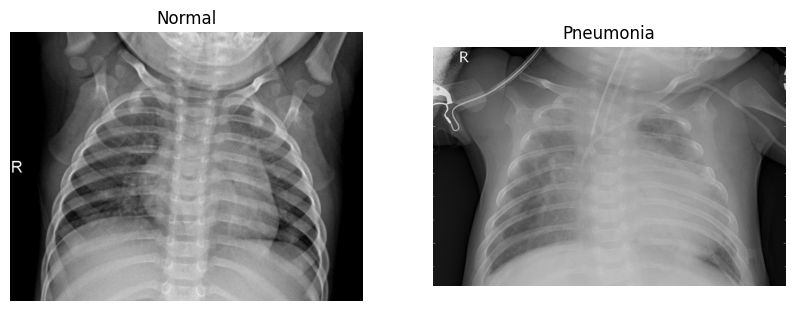

Total Images : 200
Normal Images : 100
Pneumonia Images : 100


In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(Image.open(normal_dir + '/' + os.listdir(normal_dir)[0]), cmap='gray')
plt.title("Normal")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(Image.open(pneumonia_dir + '/' + os.listdir(pneumonia_dir)[0]), cmap='gray')
plt.title("Pneumonia")
plt.axis('off')

plt.show()


print("Total Images :", len(X))
print("Normal Images :", np.sum(y==0))
print("Pneumonia Images :", np.sum(y==1))

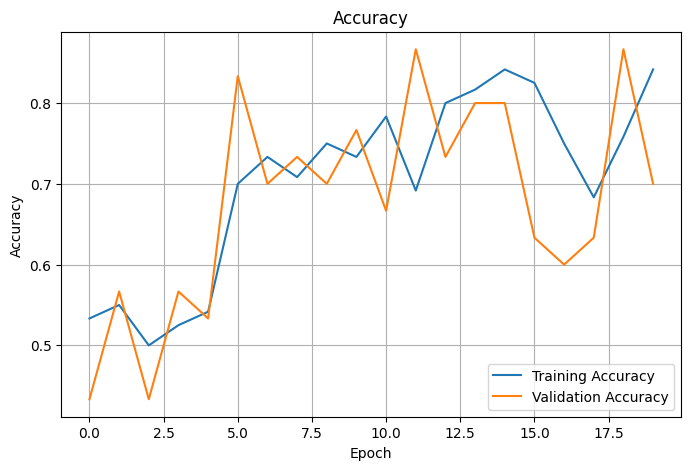

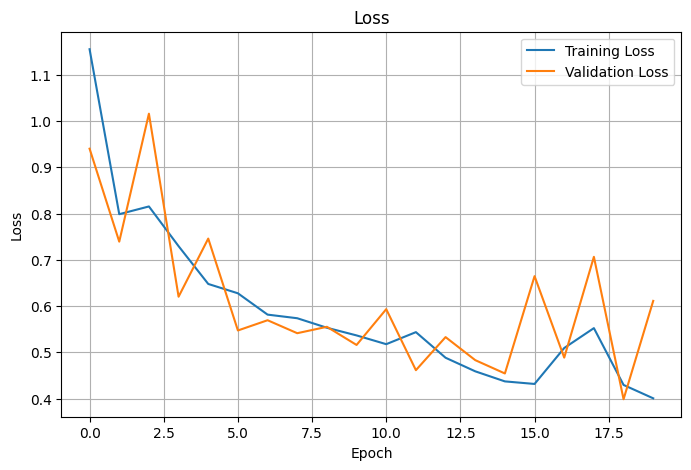

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

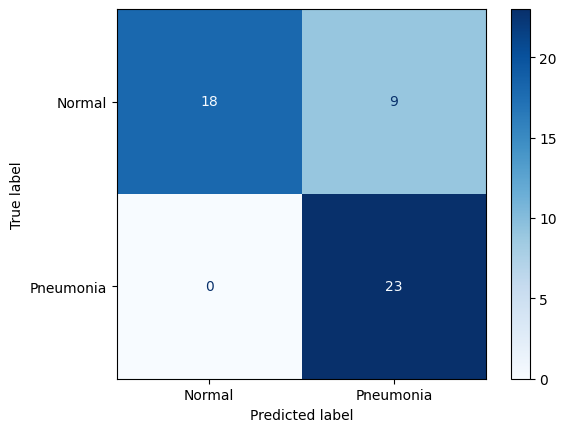

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Normal","Pneumonia"])

disp.plot(cmap="Blues")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# ================================
# Test the Model on a Custom X-ray Image
# ================================

from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image # Import PIL Image for grayscale conversion and resizing

# Upload an image
uploaded = files.upload()

# Get uploaded file name
filename = list(uploaded.keys())[0]

# Load image and preprocess it to match training data format (grayscale, 64x64, flattened)
IMG_SIZE = (64, 64) # Use the same IMG_SIZE as in training

# Load as grayscale using PIL, then resize
img = Image.open(filename).convert("L") # Convert to grayscale
img = img.resize(IMG_SIZE) # Resize to 64x64

# Display image
plt.imshow(img, cmap='gray') # Use cmap='gray' for grayscale image
plt.title("Uploaded Chest X-ray")
plt.axis('off')
plt.show()

# Preprocess image for model prediction
img_array = np.array(img).flatten() # Convert to array and flatten
img_array = img_array / 255.0 # Normalize pixel values
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension (shape: (1, 4096))

# Predict
prediction = model.predict(img_array)

# Get predicted class and confidence for sigmoid output
predicted_probability = prediction[0][0] # Get the probability of class 1 (Pneumonia)

if predicted_probability >= 0.5:
    label = "Pneumonia"
    confidence = predicted_probability * 100
else:
    label = "Normal"
    confidence = (1 - predicted_probability) * 100 # Confidence in the predicted normal class

print("="*40)
print("Prediction :", label)
print(f"Confidence : {confidence:.2f}%")
print("="*40)

In [15]:
model.save("Pneumonia_Detection_Model.keras")